# Computer Exercise 13.2 — Problem 5

## 비선형 최소제곱: Gauss–Newton 대 Levenberg–Marquardt

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.2 Minimization of Multivariate Functions (continued)
> **풀이 일자**: Day 47
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **5.** Given data $\{(t_i, y_i)\}_{i=1}^m$ and a nonlinear model
> $\phi(t;\mathbf{x})$, minimize $f(\mathbf{x}) = \tfrac12\sum_{i=1}^m r_i(\mathbf{x})^2$
> with $r_i = \phi(t_i;\mathbf{x}) - y_i$. Implement the **Gauss–Newton** method
> (using $J^\top J$ as an approximate Hessian) and the **Levenberg–Marquardt**
> method (solving $(J^\top J + \lambda I)\,\mathbf{p} = -J^\top \mathbf{r}$).
> Fit the exponential model $\phi(t;\mathbf{x}) = x_1 e^{x_2 t}$ to noisy data, and
> show that from a poor starting point Gauss–Newton **diverges** (the step
> overshoots and the model blows up) while Levenberg–Marquardt **converges**.

### 한국어 풀이용 정리
잔차 벡터 $\mathbf r(\mathbf x)$ 의 야코비안 $J$ 만으로 헤시안을 $J^\top J$ 로 근사하면 Gauss–Newton 이다.
하지만 출발점이 나쁘면(여기서는 $x_2$ 의 부호가 틀려 지수가 폭증) Gauss–Newton 스텝이 *과도하게 튀어*
모델이 오버플로로 발산한다. **Levenberg–Marquardt** 는 $\lambda I$ 를 더해 스텝을 짧은 최급강하 쪽으로
당겨 안전지대로 끌어온 뒤, 잔차가 줄면 $\lambda$ 를 낮춰 Gauss–Newton 의 빠른 수렴으로 전환한다.

## 2. 수학적 배경

### 2.1 최소제곱의 기울기와 헤시안
$$\nabla f = J^\top \mathbf r,\qquad
\nabla^2 f = J^\top J + \sum_{i=1}^m r_i \nabla^2 r_i .$$
잔차가 작거나 모델이 거의 선형이면 둘째 항을 버려 $\nabla^2 f \approx J^\top J$ (Gauss–Newton 근사).

### 2.2 Gauss–Newton 스텝
$$\boxed{\;(J^\top J)\,\mathbf p^{\mathrm{GN}} = -J^\top \mathbf r\;}$$
나쁜 출발점에서 $J$ 의 열이 거의 평행(지수가 폭증)하면 $J^\top J$ 가 악조건이 되어 스텝이 폭주한다.

### 2.3 Levenberg–Marquardt 스텝
$$\boxed{\;(J^\top J + \lambda I)\,\mathbf p^{\mathrm{LM}} = -J^\top \mathbf r\;}$$
- $\lambda\to 0$: Gauss–Newton (빠른 수렴)
- $\lambda\to\infty$: $\mathbf p\approx -\tfrac1\lambda J^\top\mathbf r$ (짧은 최급강하 스텝, 안전)

$\lambda$ 는 스텝이 함수값을 줄이면 나누고(÷), 늘리면 곱한다(×). 이는 Problem 4 의 신뢰영역 반지름
조절과 등가다 (Problem 6 에서 정량 확인).

## 3. 풀이 흐름

1. **합성 데이터**: 참값 $\mathbf x^\*=(2.5,\,-1.3)$ 로 $\phi(t)=x_1 e^{x_2 t}$ 를 만들고 가우시안 잡음 추가 ($m=40$).
2. **잔차·야코비안** 해석적 구현: $r_i,\ J_{i1}=e^{x_2 t_i},\ J_{i2}=x_1 t_i e^{x_2 t_i}$.
3. **Gauss–Newton** 구현: $(J^\top J)\mathbf p=-J^\top\mathbf r$.
4. **Levenberg–Marquardt** 구현: $\lambda$ 적응(성공 시 ÷3, 실패 시 ×3).
5. **나쁜 출발점** $(2.5,\,2.0)$ ($x_2$ 부호 반대) 에서 두 방법 실행 — GN 발산 / LM 수렴.
6. **표**: GN 의 목적함수 폭증, LM 의 $\lambda$ 궤적.
7. **시각화**: 데이터+적합 곡선, 목적함수 수렴 곡선.
8. **해석**: 감쇠가 왜 안정성을 사는가.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:.4e}')
rng = np.random.default_rng(11)

# --- 합성 데이터: phi(t) = x1 exp(x2 t),  참값 (2.5, -1.3) ---
xtrue = np.array([2.5, -1.3])
t = np.linspace(0.0, 3.0, 40)
def model(x, t):
    return x[0]*np.exp(x[1]*t)
y = model(xtrue, t) + 0.02*rng.standard_normal(t.size)

def residual(x):
    return model(x, t) - y
def jacobian(x):
    e = np.exp(x[1]*t)
    return np.column_stack([e, x[0]*t*e])      # dr/dx1, dr/dx2
def fobj(x):
    r = residual(x); return 0.5*r @ r

def gauss_newton(x0, tol=1e-10, maxit=60):
    x = np.array(x0, float); hist = [fobj(x)]; status = 'ok'
    with np.errstate(over='ignore', invalid='ignore'):
        for k in range(maxit):
            J = jacobian(x); r = residual(x); g = J.T @ r
            if np.linalg.norm(g) < tol:
                break
            try:
                p = np.linalg.solve(J.T @ J, -g)
            except np.linalg.LinAlgError:
                status = 'singular'; break
            x = x + p; hist.append(fobj(x))
            if not np.all(np.isfinite(x)) or fobj(x) > 1e8:
                status = 'DIVERGED'; break
    return x, hist, status

def levenberg_marquardt(x0, lam0=1e-2, tol=1e-10, maxit=200):
    x = np.array(x0, float); lam = lam0
    hist = [fobj(x)]; rec = []
    for k in range(maxit):
        J = jacobian(x); r = residual(x); g = J.T @ r
        gn = np.linalg.norm(g)
        if gn < tol:
            rec.append((k, fobj(x), gn, lam)); break
        JTJ = J.T @ J; I = np.eye(len(x))
        while True:
            p = np.linalg.solve(JTJ + lam*I, -g)
            if fobj(x + p) < fobj(x):
                x = x + p; lam = max(lam/3, 1e-12); break    # 수락 -> 감쇠 완화
            lam *= 3                                          # 기각 -> 감쇠 강화
            if lam > 1e14:
                break
        hist.append(fobj(x)); rec.append((k, fobj(x), gn, lam))
        if lam > 1e14:
            break
    return x, hist, rec

bad = np.array([2.5, 2.0])           # 나쁜 출발점: x2 부호 반대 -> 지수 폭증
xgn, hgn, sgn = gauss_newton(bad)
xlm, hlm, reclm = levenberg_marquardt(bad)

print(f'참값             : {xtrue}')
print(f'Gauss-Newton     : status = {sgn},  f = {hgn[-1]:.3e},  반복 = {len(hgn)-1},  x = {np.round(xgn,3)}')
print(f'Levenberg-Marq.  : 수렴,           f = {fobj(xlm):.3e},  반복 = {len(reclm)},  x = {np.round(xlm,4)}')

참값             : [ 2.5 -1.3]
Gauss-Newton     : status = DIVERGED,  f = 7.708e+46,  반복 = 5,  x = [ 2.13  17.846]
Levenberg-Marq.  : 수렴,           f = 5.393e-03,  반복 = 11,  x = [ 2.515  -1.3113]


In [2]:
# --- GN 발산 궤적 & LM 의 lambda 궤적 ---
print('Gauss-Newton 목적함수 추이 (폭증):')
print('  ', [f'{v:.2e}' for v in hgn])
print()
dflm = pd.DataFrame(reclm, columns=['k', 'f', '||grad||', 'lambda'])
print('Levenberg-Marquardt 반복 기록 (처음/끝):')
print(pd.concat([dflm.head(7), dflm.tail(3)]).to_string(index=False))

Gauss-Newton 목적함수 추이 (폭증):
   ['1.92e+06', '1.29e+02', '3.11e+01', '1.55e+01', '1.24e+01', '7.71e+46']

Levenberg-Marquardt 반복 기록 (처음/끝):
 k          f   ||grad||     lambda
 0 1.2872e+02 1.0810e+07 3.3333e-03
 1 3.1060e+01 1.1634e+04 1.1111e-03
 2 1.5518e+01 1.5564e+03 3.7037e-04
 3 1.2366e+01 1.8778e+01 1.2346e-04
 4 1.0680e+00 5.2886e+00 3.0000e-02
 5 5.7320e-03 4.6803e+00 1.0000e-02
 6 5.3927e-03 7.2752e-02 3.3333e-03
 8 5.3927e-03 1.4326e-06 3.7037e-04
 9 5.3927e-03 5.6749e-09 1.2346e-04
10 5.3927e-03 2.4257e-11 1.2346e-04


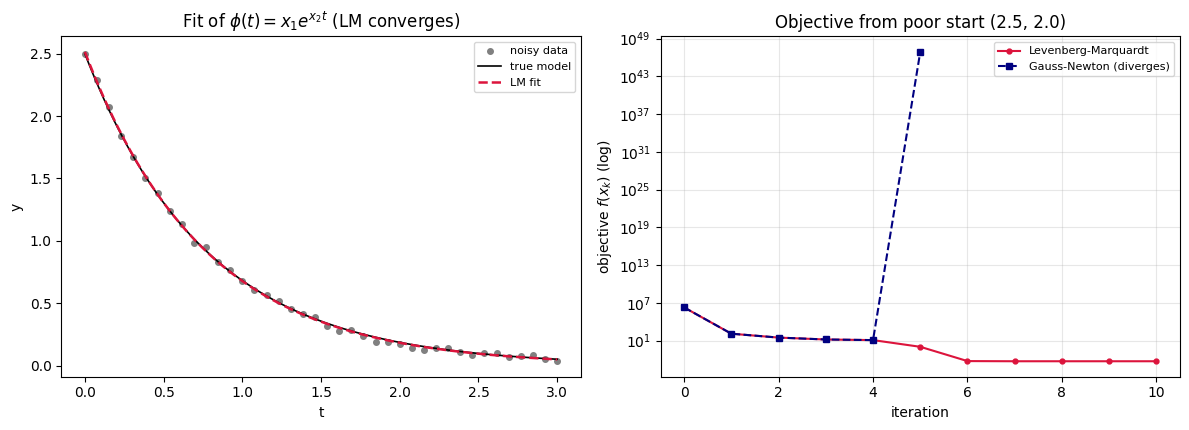

In [3]:
# --- 데이터 + 적합 곡선, 목적함수 수렴 ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
tt = np.linspace(0, 3, 200)
ax[0].plot(t, y, 'o', ms=4, color='gray', label='noisy data')
ax[0].plot(tt, model(xtrue, tt), '-', color='black', lw=1.2, label='true model')
ax[0].plot(tt, model(xlm, tt), '--', color='crimson', lw=1.8, label='LM fit')
ax[0].set_xlabel('t'); ax[0].set_ylabel('y')
ax[0].set_title(r'Fit of $\phi(t)=x_1 e^{x_2 t}$ (LM converges)'); ax[0].legend(fontsize=8)

ax[1].semilogy(range(len(hlm)), np.maximum(hlm, 1e-16), 'o-', ms=3.5, color='crimson', label='Levenberg-Marquardt')
hg = np.array(hgn); hg = np.where(np.isfinite(hg), hg, np.nan)
ax[1].semilogy(range(len(hg)), np.maximum(np.abs(hg), 1e-16), 's--', ms=5, color='navy', label='Gauss-Newton (diverges)')
ax[1].set_xlabel('iteration'); ax[1].set_ylabel(r'objective $f(x_k)$ (log)')
ax[1].set_title('Objective from poor start (2.5, 2.0)')
ax[1].grid(True, which='both', alpha=0.3); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **나쁜 출발점에서 갈린다**: 출발 $(2.5,2.0)$ 은 $x_2$ 의 *부호*가 참값과 반대라 $e^{x_2 t}$ 가 폭증한다.
   Gauss–Newton 은 $J^\top J$ 만 믿고 큰 스텝을 던져 목적함수가 $10^{40}$ 이상으로 **발산**하고 몇 스텝 만에
   오버플로로 멈춘다.
2. **LM 의 감쇠 효과**: Levenberg–Marquardt 는 초반에 스텝이 함수값을 못 줄이면 $\lambda$ 를 $\times3$ 씩 키워
   *짧은 최급강하* 스텝으로 만들어 안전지대로 끌어온다. 표의 $\lambda$ 열이 위기 구간에서 솟구쳤다가 잔차가
   줄면서 $\div3$ 으로 내려가는 것을 볼 수 있다.
3. **속도-안전 자동 절충**: 안전지대에 들어선 뒤에는 $\lambda$ 가 바닥으로 내려가 Gauss–Newton 에 가까운
   빠른 수렴으로 전환되어, 결국 참 모델과 거의 겹치는 곡선을 복원한다($f$ 가 잡음 수준 $\sim10^{-3}$ 까지 감소).
4. **교훈**: Gauss–Newton 은 *좋은 출발점·작은 잔차* 에서 거의 2차로 빠르지만, 나쁜 출발점에서는 신뢰할 수
   없다. $\lambda I$ 한 항이 전역적 안정성을 산다.

> **결론**: Gauss–Newton 은 빠르지만 불안정하고, Levenberg–Marquardt 는 $\lambda I$ 로 항상 양정치를
> 보장해 **나쁜 출발점에서도 수렴**한다 — 비선형 최소제곱의 표준 작업마(workhorse)인 이유다.

**다음 문제로의 연결** — Problem 6 에서는 이 $\lambda$ 가 단순한 정칙화가 아니라 **신뢰영역 반지름과 등가**임을
($\|\mathbf p(\lambda)\|$ 단조 감소) 수치로 보이고, 고정-$\lambda$ / Marquardt 적응 / 신뢰영역 세 전략을 직접 대조한다.